In [1]:
from pyspark.sql import SparkSession
from pyspark.ml.clustering import KMeansModel

# 1. Iniciamos Spark
spark = SparkSession.builder.appName("S12_Supervisados").getOrCreate()

# 2. CARGAR LOS DATOS (Esto lee el parquet donde guardaste los clusters)
# Asegúrate que esta ruta contenga archivos tipo 'part-00000...'
ruta_datos = "/home/jovyan/work/semanas/Semana 10/modelos/datos_etiquetados_kmeans"
df_clusters = spark.read.parquet(ruta_datos)

print("✅ Datos recuperados:")
df_clusters.show(5)

# 3. CARGAR EL MODELO (Aquí cargamos el "cerebro" para clasificar nuevos datos)
# Nota: La ruta debe ser la misma que usaste en .save()
ruta_modelo = "/home/jovyan/work/semanas/Semana 10/modelos/kmeans_inmobiliario_v1"
model_recuperado = KMeansModel.load(ruta_modelo)

print("✅ Modelo cargado y listo para nuevas predicciones.")

✅ Datos recuperados:
+--------------------+-----+-----------+--------------------+---------------+-------------------+--------+--------------------+----------+---+-------+-------+-------+----------------+-------+--------------------+---------+--------------------+--------------------+----------+
|                 _id|banos|dormitorios|              enlace|estacionamiento|   fecha_extraccion|gimnasio|              imagen|lavanderia| m2|piscina| precio|quincho|     responsable|terraza|              titulo|ubicacion|            features|      scaledFeatures|prediction|
+--------------------+-----+-----------+--------------------+---------------+-------------------+--------+--------------------+----------+---+-------+-------+-------+----------------+-------+--------------------+---------+--------------------+--------------------+----------+
|https://casas.mit...|    1|          2|https://casas.mit...|              1|2026-05-01 21:12:48|       0|https://img.mitul...|         0| 44|      1| 

In [3]:
from pyspark.sql.functions import col, when
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import DecisionTreeClassifier

# 1. FILTRADO INICIAL
df_limpio = df_clusters.filter(
    (col("precio") >= 100000) & (col("precio") <= 2500000) &
    (col("m2").isNotNull()) & (col("m2") > 0) & (col("m2") <= 400)
)

# 2. CONVERSIÓN DE AMENIDADES A ENTERO
columnas_amenidades = ["estacionamiento", "gimnasio", "lavanderia", "piscina", "quincho", "terraza"]
for col_name in columnas_amenidades:
    df_limpio = df_limpio.withColumn(col_name, col(col_name).cast("int"))

# 3. AHORA RELLENAMOS LOS NULOS CON 0 (Usando el método de DataFrame)
df_limpio = df_limpio.fillna(0, subset=columnas_amenidades)

# 4. ENSAMBLADO
input_cols = ["m2", "dormitorios", "banos"] + columnas_amenidades
assembler = VectorAssembler(inputCols=input_cols, outputCol="features_supervisadas", handleInvalid="skip")
df_ensamblado = assembler.transform(df_limpio)

# 5. ESCALADO
scaler = StandardScaler(inputCol="features_supervisadas", outputCol="scaledFeatures_supervisadas")
scaler_model = scaler.fit(df_ensamblado)
df_final = scaler_model.transform(df_ensamblado)

# 6. DIVISIÓN
df_supervisado = df_final.withColumnRenamed("prediction", "label")
train_data, test_data = df_supervisado.randomSplit([0.7, 0.3], seed=42)

# 6.5 CREACIÓN Y ENTRENAMIENTO DEL MODELO DE ÁRBOL DE DECISIÓN
# Definimos el clasificador
dt = DecisionTreeClassifier(featuresCol="scaledFeatures_supervisadas", labelCol="label")

# Entrenamos el modelo usando los datos de entrenamiento (train_data)
dt_model = dt.fit(train_data)

print("✅ Modelo Decision Tree entrenado exitosamente.")

# 7. PREDICCIONES
predictions = dt_model.transform(test_data)

# 8. VISUALIZAMOS (Agregando la columna 'probability')
print("=== PREDICCIONES: TÍTULO, ETIQUETA, PREDICCIÓN Y PROBABILIDAD ===")

# Ajustamos el título por si viene vacío
from pyspark.sql.functions import col, when
predictions = predictions.withColumn(
    "titulo_visual", 
    when((col("titulo") == "") | col("titulo").isNull(), "Sin título").otherwise(col("titulo"))
)

# Mostramos la probabilidad junto a los demás datos
# La columna 'probability' mostrará el vector de confianza del modelo
predictions.select("titulo_visual", "label", "prediction", "probability").show(10, truncate=False)

✅ Modelo Decision Tree entrenado exitosamente.
=== PREDICCIONES: TÍTULO, ETIQUETA, PREDICCIÓN Y PROBABILIDAD ===
+--------------------------------------------------+-----+----------+-----------------------------+
|titulo_visual                                     |label|prediction|probability                  |
+--------------------------------------------------+-----+----------+-----------------------------+
|Sin título                                        |5    |5.0       |[0.0,0.0,0.0,0.0,0.0,1.0,0.0]|
|Departamento Puerta mar ID: 167413r               |5    |5.0       |[0.0,0.0,0.0,0.0,0.0,1.0,0.0]|
|Departamento Puerta mar ID: 167367r               |0    |0.0       |[1.0,0.0,0.0,0.0,0.0,0.0,0.0]|
|Sin título                                        |0    |0.0       |[1.0,0.0,0.0,0.0,0.0,0.0,0.0]|
|Sin título                                        |0    |0.0       |[1.0,0.0,0.0,0.0,0.0,0.0,0.0]|
|Sin título                                        |0    |0.0       |[1.0,0.0,0.0,0.0,0

In [4]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# =====================================================================
# PASO 8: EVALUACIÓN DEL MODELO (MATRIZ DE CONFUSIÓN Y ACCURACY)
# =====================================================================

# 1. Configurar el evaluador para medir el Accuracy
# Usamos 'label' (que viene del K-Means) y 'prediction' (la del Árbol)
evaluator = MulticlassClassificationEvaluator(
    labelCol="label", 
    predictionCol="prediction", 
    metricName="accuracy"
)

# 2. Calcular la precisión sobre los datos de prueba
# OJO: Aquí usamos 'predictions' (el nombre real de tu variable)
accuracy = evaluator.evaluate(predictions)

# 3. Imprimir resultado
print("==================================================")
print(" RESULTADOS DE CLASIFICACIÓN (CON AMENIDADES) ")
print("==================================================")
print(f"Precisión del Árbol de Decisión (Accuracy): {accuracy * 100:.2f}%")
print("==================================================")

 RESULTADOS DE CLASIFICACIÓN (CON AMENIDADES) 
Precisión del Árbol de Decisión (Accuracy): 99.60%


In [5]:
# =====================================================================
# PASO 8: VISUALIZAR LA LÓGICA DEL ÁRBOL
# =====================================================================

print("=== ESTRUCTURA LÓGICA DEL ÁRBOL ===")
print(dt_model.toDebugString)

=== ESTRUCTURA LÓGICA DEL ÁRBOL ===
DecisionTreeClassificationModel: uid=DecisionTreeClassifier_646be93f634d, depth=2, numNodes=7, numClasses=7, numFeatures=9
  If (feature 2 <= 2.6484776194590234)
   If (feature 1 <= 2.342943808355257)
    Predict: 5.0
   Else (feature 1 > 2.342943808355257)
    Predict: 4.0
  Else (feature 2 > 2.6484776194590234)
   If (feature 1 <= 17.3377841818289)
    Predict: 0.0
   Else (feature 1 > 17.3377841818289)
    Predict: 6.0



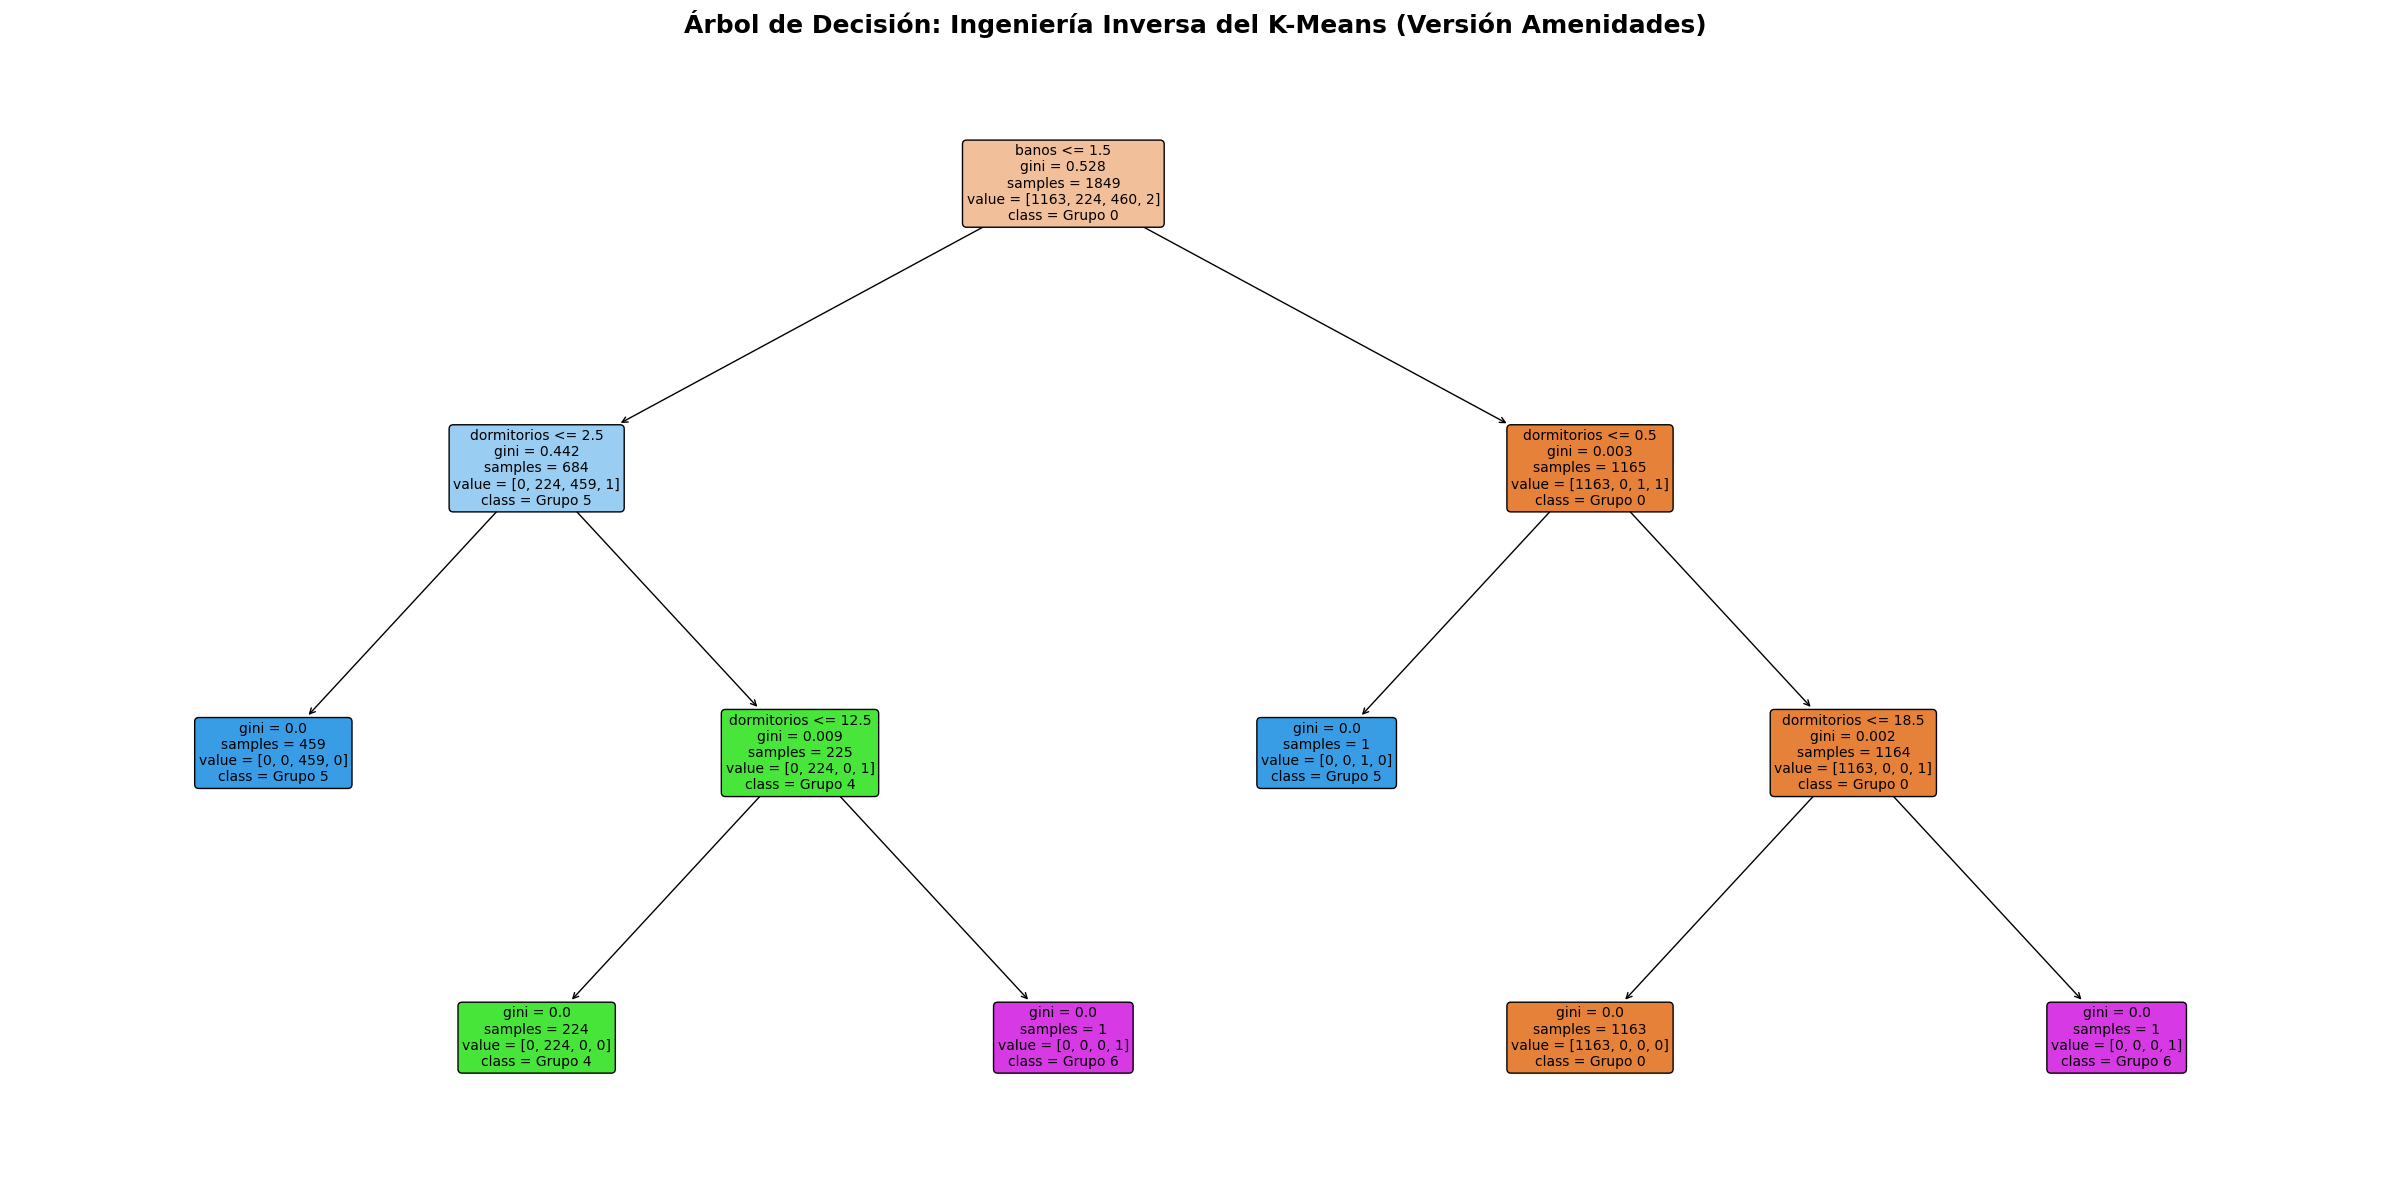

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier as SklearnClassifier

# =====================================================================
# PASO 9: VISUALIZACIÓN GRÁFICA DEL ÁRBOL (CON AMENIDADES)
# =====================================================================

# 1. Convertimos una muestra de nuestro DataFrame de Spark a Pandas
# Incluimos todas las columnas que ahora componen tu modelo
columnas_modelo = ["m2", "dormitorios", "banos", "estacionamiento", "gimnasio", "lavanderia", "piscina", "quincho", "terraza"]
df_pandas = df_supervisado.select(*(columnas_modelo + ["label"])).toPandas()

# 2. Separamos las características (X) y la etiqueta (y)
X_muestra = df_pandas[columnas_modelo]
y_muestra = df_pandas["label"]

# 3. Entrenamos el modelo de Scikit-Learn
# max_depth=3 sigue siendo recomendable para que el gráfico sea legible
sk_dt = SklearnClassifier(max_depth=3, random_state=42)
sk_dt.fit(X_muestra, y_muestra)

# 4. Configuramos las etiquetas y nombres para el gráfico
nombres_features = columnas_modelo
# Convertimos los números de cluster a texto para que sea más didáctico
nombres_clases = [f"Grupo {int(c)}" for c in sorted(y_muestra.unique())]

# 5. Dibujamos el árbol de forma visual
plt.figure(figsize=(24, 12), dpi=100) # Un poco más ancho para que quepan las nuevas variables
plot_tree(
    sk_dt,
    feature_names=nombres_features,
    class_names=nombres_clases,
    filled=True,      # Colores según la clase mayoritaria
    rounded=True,     # Bordes redondeados
    fontsize=10       # Letra ligeramente más pequeña para que quepa todo
)

plt.title("Árbol de Decisión: Ingeniería Inversa del K-Means (Versión Amenidades)", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
from pyspark.sql.functions import col, when
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import DecisionTreeClassifier

# 1. FILTRADO: Eliminamos valores atípicos y nulos críticos en m2
df_limpio = df_clusters.filter(
    (col("precio") >= 100000) & (col("precio") <= 2500000) &
    (col("m2").isNotNull()) & (col("m2") > 0) & (col("m2") <= 400)
)

# 2. ASEGURAR FORMATO: Convertimos las amenidades a entero
columnas_amenidades = ["estacionamiento", "gimnasio", "lavanderia", "piscina", "quincho", "terraza"]

for c in columnas_amenidades:
    df_limpio = df_limpio.withColumn(c, col(c).cast("int"))

# 3. AQUÍ ESTÁ LA CORRECCIÓN: Aplicamos fillna al DataFrame completo
# Esto reemplaza los nulos por 0 solo en las columnas de amenidades
df_limpio = df_limpio.fillna(0, subset=columnas_amenidades)

# 4. ENSAMBLADO: Ahora que los datos están limpios, ensamblamos
input_cols = ["m2", "dormitorios", "banos"] + columnas_amenidades
assembler = VectorAssembler(inputCols=input_cols, outputCol="features_supervisadas", handleInvalid="skip")
df_ensamblado = assembler.transform(df_limpio)

# 5. ESCALADO
scaler = StandardScaler(inputCol="features_supervisadas", outputCol="scaledFeatures_supervisadas")
scaler_model = scaler.fit(df_ensamblado)
df_final = scaler_model.transform(df_ensamblado)

# 6. RENOMBRAMOS Y DIVIDIMOS
df_supervisado = df_final.withColumnRenamed("prediction", "label")
train_data, test_data = df_supervisado.randomSplit([0.7, 0.3], seed=42)

# 7. ENTRENAMOS EL ÁRBOL DE DECISIÓN
dt = DecisionTreeClassifier(
    featuresCol="scaledFeatures_supervisadas", 
    labelCol="label", 
    maxDepth=5, 
    seed=42
)
dt_model = dt.fit(train_data)

# 8. PREDICCIONES
predictions = dt_model.transform(test_data)

# 9. VISUALIZAMOS CON TÍTULO Y PROBABILIDAD
print("=== PREDICCIONES: TÍTULO, ETIQUETA, PREDICCIÓN Y PROBABILIDAD ===")
predictions = predictions.withColumn(
    "titulo_visual", 
    when((col("titulo") == "") | col("titulo").isNull(), "Sin título").otherwise(col("titulo"))
)
predictions.select("titulo_visual", "label", "prediction", "probability").show(10, truncate=False)

=== PREDICCIONES: TÍTULO, ETIQUETA, PREDICCIÓN Y PROBABILIDAD ===
+--------------------------------------------------+-----+----------+-----------------------------+
|titulo_visual                                     |label|prediction|probability                  |
+--------------------------------------------------+-----+----------+-----------------------------+
|Sin título                                        |5    |5.0       |[0.0,0.0,0.0,0.0,0.0,1.0,0.0]|
|Departamento Puerta mar ID: 167413r               |5    |5.0       |[0.0,0.0,0.0,0.0,0.0,1.0,0.0]|
|Departamento Puerta mar ID: 167367r               |0    |0.0       |[1.0,0.0,0.0,0.0,0.0,0.0,0.0]|
|Sin título                                        |0    |0.0       |[1.0,0.0,0.0,0.0,0.0,0.0,0.0]|
|Sin título                                        |0    |0.0       |[1.0,0.0,0.0,0.0,0.0,0.0,0.0]|
|Sin título                                        |0    |0.0       |[1.0,0.0,0.0,0.0,0.0,0.0,0.0]|
|Arriendo departamento nuevo en La

In [8]:
train_data.groupBy("label").count().show()

+-----+-----+
|label|count|
+-----+-----+
|    6|    1|
|    5|  341|
|    4|  159|
|    0|  842|
+-----+-----+



In [9]:
from pyspark.sql.functions import col, when
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer
from pyspark.ml.classification import RandomForestClassifier, LinearSVC, LogisticRegression, OneVsRest
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# =====================================================================
# 1. PREPARACIÓN Y LIMPIEZA DE DATOS
# =====================================================================

# Filtramos outliers: precios (100k - 2.5M) y m2 (hasta 400)
df_limpio = df_clusters.filter(
    (col("precio") >= 100000) & (col("precio") <= 2500000) &
    (col("m2").isNotNull()) & (col("m2") > 0) & (col("m2") <= 400)
)

# Imputamos amenidades: Convertimos a entero y si es null -> 0
columnas_amenidades = ["estacionamiento", "gimnasio", "lavanderia", "piscina", "quincho", "terraza"]
for c in columnas_amenidades:
    df_limpio = df_limpio.withColumn(c, col(c).cast("int"))

df_limpio = df_limpio.fillna(0, subset=columnas_amenidades)

# 2. INDEXACIÓN DE CLASES (Para evitar errores con etiquetas como 0, 4, 5, 6)
# Esto convierte cualquier etiqueta en 0, 1, 2, 3...
indexer = StringIndexer(inputCol="prediction", outputCol="label_index")
df_indexado = indexer.fit(df_limpio).transform(df_limpio)

# 3. ENSAMBLADO Y ESCALADO
input_cols = ["m2", "dormitorios", "banos"] + columnas_amenidades
assembler = VectorAssembler(inputCols=input_cols, outputCol="features_supervisadas", handleInvalid="skip")
df_ensamblado = assembler.transform(df_indexado)

scaler = StandardScaler(inputCol="features_supervisadas", outputCol="scaledFeatures_supervisadas")
df_final = scaler.fit(df_ensamblado).transform(df_ensamblado)

# 4. DIVISIÓN DE DATOS
train_data, test_data = df_final.randomSplit([0.7, 0.3], seed=42)
print(f"Entrenamiento: {train_data.count()} | Prueba: {test_data.count()}")

# =====================================================================
# ENTRENAMIENTO ROBUSTO
# =====================================================================

evaluator = MulticlassClassificationEvaluator(labelCol="label_index", predictionCol="prediction", metricName="accuracy")
feat_col = "scaledFeatures_supervisadas"

# 1. Random Forest
rf = RandomForestClassifier(featuresCol=feat_col, labelCol="label_index", numTrees=20, seed=42)
rf_model = rf.fit(train_data.drop("prediction"))
rf_preds = rf_model.transform(test_data.drop("prediction"))
accuracy_rf = evaluator.evaluate(rf_preds)
print(f"Accuracy Random Forest: {accuracy_rf * 100:.2f}%")

# 2. SVM (OneVsRest)
svm_binario = LinearSVC(featuresCol=feat_col, labelCol="label_index", maxIter=10)
ovr_svm = OneVsRest(classifier=svm_binario, labelCol="label_index", featuresCol=feat_col)
svm_model = ovr_svm.fit(train_data.drop("prediction"))
svm_preds = svm_model.transform(test_data.drop("prediction"))
accuracy_svm = evaluator.evaluate(svm_preds) # <--- AQUÍ FALTABA ESTA LÍNEA
print(f"Accuracy SVM: {accuracy_svm * 100:.2f}%")

# 3. Regresión Logística
lr = LogisticRegression(featuresCol=feat_col, labelCol="label_index", maxIter=10, family="multinomial")
lr_model = lr.fit(train_data.drop("prediction"))
lr_preds = lr_model.transform(test_data.drop("prediction"))
accuracy_lr = evaluator.evaluate(lr_preds)
print(f"Accuracy Regresión Logística: {accuracy_lr * 100:.2f}%")

# =====================================================================
# 3. VISUALIZACIÓN FINAL
# =====================================================================
print("\n=== COMPARATIVA: TÍTULO, ETIQUETA, PREDICCIÓN Y PROBABILIDAD ===")
final_view = rf_preds.withColumn(
    "titulo_visual", 
    when((col("titulo") == "") | col("titulo").isNull(), "Sin título").otherwise(col("titulo"))
)
final_view.select("titulo_visual", "label_index", "prediction", "probability").show(10, truncate=False)

Entrenamiento: 1343 | Prueba: 506
Accuracy Random Forest: 99.60%
Accuracy SVM: 99.41%
Accuracy Regresión Logística: 99.80%

=== COMPARATIVA: TÍTULO, ETIQUETA, PREDICCIÓN Y PROBABILIDAD ===
+--------------------------------------------------+-----------+----------+------------------------------------------------------------------------------------+
|titulo_visual                                     |label_index|prediction|probability                                                                         |
+--------------------------------------------------+-----------+----------+------------------------------------------------------------------------------------+
|Sin título                                        |1.0        |1.0       |[0.0737944772325078,0.8224851517033608,0.10336194812506339,3.584229390681004E-4]    |
|Departamento Puerta mar ID: 167413r               |1.0        |1.0       |[0.03645916114790287,0.9276051113230193,0.03593572752907791,0.0]                    |
|Depar

In [10]:
# =====================================================================
# PASO 11.3.3: TABLA COMPARATIVA DE RESULTADOS
# =====================================================================

print("==================================================")
print(" RESULTADOS DE MODELOS SUPERVISADOS (SEMANA 12) ")
print("==================================================")
print(f"1. Random Forest Accuracy: {accuracy_rf * 100:.2f}%")
print(f"2. SVM (OneVsRest) Accuracy: {accuracy_svm * 100:.2f}%")
print(f"3. Regresión Logística Accuracy: {accuracy_lr * 100:.2f}%")
print("==================================================")

 RESULTADOS DE MODELOS SUPERVISADOS (SEMANA 12) 
1. Random Forest Accuracy: 99.60%
2. SVM (OneVsRest) Accuracy: 99.41%
3. Regresión Logística Accuracy: 99.80%


In [11]:
from pyspark.ml.classification import RandomForestClassifier, LinearSVC, LogisticRegression, OneVsRest
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# =====================================================================
# PASO 11.3.2: ENTRENAMIENTO ROBUSTO DE MODELOS
# =====================================================================

# 1. Configuración común
evaluator = MulticlassClassificationEvaluator(
    labelCol="label_index", 
    predictionCol="prediction", 
    metricName="accuracy"
)
feat_col = "scaledFeatures_supervisadas"

# 2. Definimos una función para limpiar predicciones anteriores y re-entrenar
def entrenar_y_evaluar(modelo, nombre_modelo, train, test):
    # Entrenamos eliminando explícitamente cualquier 'prediction' previa en el dataset
    modelo_fit = modelo.fit(train.drop("prediction"))
    
    # Predecimos eliminando cualquier 'prediction' previa en el test
    preds = modelo_fit.transform(test.drop("prediction"))
    
    # Evaluamos
    acc = evaluator.evaluate(preds)
    print(f"Accuracy {nombre_modelo}: {acc * 100:.2f}%")
    return preds

# ==========================================
# EJECUCIÓN DE LOS 3 MODELOS
# ==========================================

print("=== INICIANDO ENTRENAMIENTO MULTI-MODELO ===")

# Modelo 1: Random Forest
rf = RandomForestClassifier(featuresCol=feat_col, labelCol="label_index", numTrees=20, seed=42)
rf_preds = entrenar_y_evaluar(rf, "Random Forest", train_data, test_data)

# Modelo 2: SVM (OneVsRest)
svm_binario = LinearSVC(featuresCol=feat_col, labelCol="label_index", maxIter=10)
ovr_svm = OneVsRest(classifier=svm_binario, labelCol="label_index", featuresCol=feat_col)
svm_preds = entrenar_y_evaluar(ovr_svm, "SVM", train_data, test_data)

# Modelo 3: Regresión Logística
lr = LogisticRegression(featuresCol=feat_col, labelCol="label_index", maxIter=10, family="multinomial")
lr_preds = entrenar_y_evaluar(lr, "Regresión Logística", train_data, test_data)

# =====================================================================
# 3. VISUALIZACIÓN FINAL (Usando los resultados del mejor modelo, ej: Regresión Logística)
# =====================================================================
print("\n=== COMPARATIVA FINAL: MUESTRA DE RESULTADOS ===")
from pyspark.sql.functions import col, when
final_view = lr_preds.withColumn(
    "titulo_visual", 
    when((col("titulo") == "") | col("titulo").isNull(), "Sin título").otherwise(col("titulo"))
)
final_view.select("titulo_visual", "label_index", "prediction", "probability").show(10, truncate=False)

=== INICIANDO ENTRENAMIENTO MULTI-MODELO ===
Accuracy Random Forest: 99.60%
Accuracy SVM: 99.41%
Accuracy Regresión Logística: 99.80%

=== COMPARATIVA FINAL: MUESTRA DE RESULTADOS ===
+--------------------------------------------------+-----------+----------+--------------------------------------------------------------------------------------+
|titulo_visual                                     |label_index|prediction|probability                                                                           |
+--------------------------------------------------+-----------+----------+--------------------------------------------------------------------------------------+
|Sin título                                        |1.0        |1.0       |[7.224162591144636E-6,0.9938221164148663,0.00616953152895401,1.1278935886082424E-6]   |
|Departamento Puerta mar ID: 167413r               |1.0        |1.0       |[1.064260062923525E-5,0.9954901848279701,0.004498504417302392,6.681540982757903E-7]   |
|

In [12]:
from pyspark.sql.functions import col, when
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression

# =====================================================================
# 11.4.1: PREPARACIÓN DE LOS DATOS PARA REGRESIÓN (CON AMENIDADES)
# =====================================================================

# 1. Renombramos 'precio' a 'label' y manejamos los títulos vacíos
df_prep = df_clusters.withColumnRenamed("precio", "label") \
                     .withColumn("titulo", when((col("titulo") == "") | col("titulo").isNull(), "Sin título").otherwise(col("titulo")))

# 2. Convertimos amenidades a numérico y rellenamos nulos con 0
columnas_amenidades = ["estacionamiento", "gimnasio", "lavanderia", "piscina", "quincho", "terraza"]
for c in columnas_amenidades:
    df_prep = df_prep.withColumn(c, col(c).cast("int"))

df_prep = df_prep.fillna(0, subset=columnas_amenidades)

# 3. VectorAssembler: Incluimos amenidades junto a las variables base
# inputCols ahora tiene 9 variables en total (3 base + 6 amenidades)
input_cols = ["dormitorios", "banos", "m2"] + columnas_amenidades

assembler_regresion = VectorAssembler(
    inputCols=input_cols,
    outputCol="features_regresion"
)
df_vector_reg = assembler_regresion.transform(df_prep)

# 4. Escalamos las características (Obligatorio para Regresión Lineal)
scaler_reg = StandardScaler(
    inputCol="features_regresion", 
    outputCol="scaledFeatures_regresion"
)
scaler_model_reg = scaler_reg.fit(df_vector_reg)
df_para_regresion = scaler_model_reg.transform(df_vector_reg)

# 5. Limpieza: Borramos columnas que no sirven para el modelo
# Mantenemos 'titulo' y 'label' para la comparativa final
columnas_a_borrar = ["prediction", "enlace", "imagen", "ubicacion", "fecha_extraccion", "responsable", "features_regresion"]
df_para_regresion = df_para_regresion.drop(*columnas_a_borrar)

# 6. EL FILTRO MÁGICO (Limpieza de outliers)
df_regresion_limpio = df_para_regresion.filter(
    (col("label") <= 2500000) &
    (col("label") >= 100000) &
    (col("m2").isNotNull()) &
    (col("m2") <= 400)
)

# 7. División
train_reg, test_reg = df_regresion_limpio.randomSplit([0.7, 0.3], seed=42)
print(f"Datos limpios para regresión - Entrenamiento: {train_reg.count()} | Prueba: {test_reg.count()}")

Datos limpios para regresión - Entrenamiento: 1609 | Prueba: 606


In [13]:
# =====================================================================
# 11.4.2 ENTRENAR EL MODELO DE REGRESIÓN LINEAL (CON AMENIDADES)
# =====================================================================

# 1. Configurar el modelo
# Usamos 'scaledFeatures_regresion' que incluye todas las variables nuevas
lr_regresion = LinearRegression(
    featuresCol="scaledFeatures_regresion",
    labelCol="label",
    maxIter=10
)

print("📈 Entrenando el modelo de Regresión Lineal...")
lr_reg_model = lr_regresion.fit(train_reg)

# 2. Hacer las predicciones
predictions_regresion = lr_reg_model.transform(test_reg)

# 3. Mostrar comparativa con título
print("=== COMPARATIVA: PRECIO REAL VS PRECIO PREDICHO ===")
predictions_regresion.select("titulo", "label", "prediction").show(10, truncate=False)

# =====================================================================
# 11.4.3 EVALUAR EL MODELO DE REGRESIÓN (MÉTRICAS)
# =====================================================================

from pyspark.ml.evaluation import RegressionEvaluator

# 1. Configurar los evaluadores
evaluator_r2 = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="r2")
evaluator_rmse = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")

# 2. Calcular las métricas
r2 = evaluator_r2.evaluate(predictions_regresion)
rmse = evaluator_rmse.evaluate(predictions_regresion)

# 3. Imprimir el cuadro resumen
print("==================================================")
print(" 📊 EVALUACIÓN DE LA REGRESIÓN INMOBILIARIA ")
print("==================================================")
print(f"R² (Poder predictivo del modelo): {r2 * 100:.2f}%")
print(f"RMSE (Margen de error promedio en $): {rmse:,.2f}")
print("==================================================")

📈 Entrenando el modelo de Regresión Lineal...
=== COMPARATIVA: PRECIO REAL VS PRECIO PREDICHO ===
+--------------------------------------------------+------+------------------+
|titulo                                            |label |prediction        |
+--------------------------------------------------+------+------------------+
|Sin título                                        |550000|489750.1283932385 |
|Departamento Puerta mar ID: 167413r               |520000|462683.0449670212 |
|Departamento Puerta mar ID: 167367r               |360000|610920.9891779908 |
|Sin título                                        |348500|603427.7156796257 |
|Sin título                                        |490000|624080.6962259687 |
|Sin título                                        |650000|639113.9062781809 |
|Arriendo departamento nuevo en La Herradura       |500000|601259.1136564077 |
|Arriendo Departamento Nova Alto Hacienda, Coquimbo|570000|539335.4996263357 |
|Sin título                      

In [14]:
# =====================================================================
# IMPRIMIR INTERSECCIÓN Y COEFICIENTES (MODELO MULTIVARIABLE)
# =====================================================================

# Lista de columnas en el mismo orden que las incluiste en el VectorAssembler
input_cols = ["dormitorios", "banos", "m2", "estacionamiento", "gimnasio", "lavanderia", "piscina", "quincho", "terraza"]

print(f"Intersección (Precio base estimado si todo fuera cero): {lr_reg_model.intercept:.4f}")

print("\nCoeficientes (Peso de cada variable en el precio):")
for i, feature in enumerate(input_cols):
    # Accedemos al coeficiente usando el índice i
    coeficiente = lr_reg_model.coefficients[i]
    print(f"Coeficiente de '{feature}': {coeficiente:.4f}")

Intersección (Precio base estimado si todo fuera cero): 297183.5549

Coeficientes (Peso de cada variable en el precio):
Coeficiente de 'dormitorios': 6560.2877
Coeficiente de 'banos': 68999.4358
Coeficiente de 'm2': 584910.9898
Coeficiente de 'estacionamiento': 82.6293
Coeficiente de 'gimnasio': 20773.5726
Coeficiente de 'lavanderia': 4722.5979
Coeficiente de 'piscina': 9915.4806
Coeficiente de 'quincho': -17617.8697
Coeficiente de 'terraza': 1151.1769
